# Student Mental Health Analysis

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Student Mental health.csv')

# Rename columns for easier access
df.columns = ['Timestamp', 'Gender', 'Age', 'Course', 'Year', 'CGPA',
              'Marital', 'Depression', 'Anxiety', 'Panic_attack', 'Treatment']

# Strip whitespace from CGPA
df['CGPA'] = df['CGPA'].str.strip()

df.head()

,Timestamp,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic_attack,Treatment
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


## Exercise 1 — Distribution of CGPA

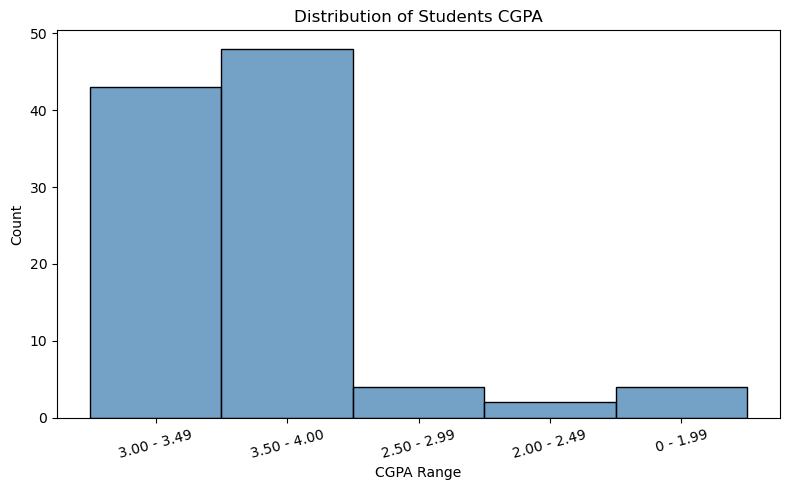

In [3]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='CGPA', color='steelblue')

plt.title('Distribution of Students CGPA')
plt.xlabel('CGPA Range')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Exercise 2 — Anxiety Levels Across Genders

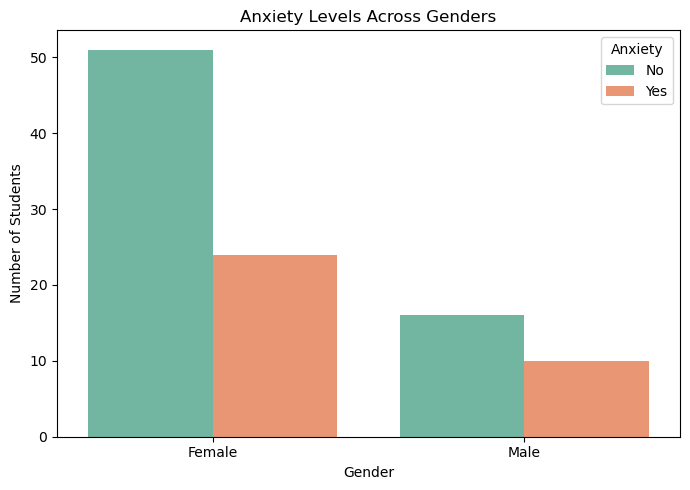

In [4]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Gender', hue='Anxiety', palette='Set2')

plt.title('Anxiety Levels Across Genders')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

## Exercise 3 — Age vs Panic Attacks

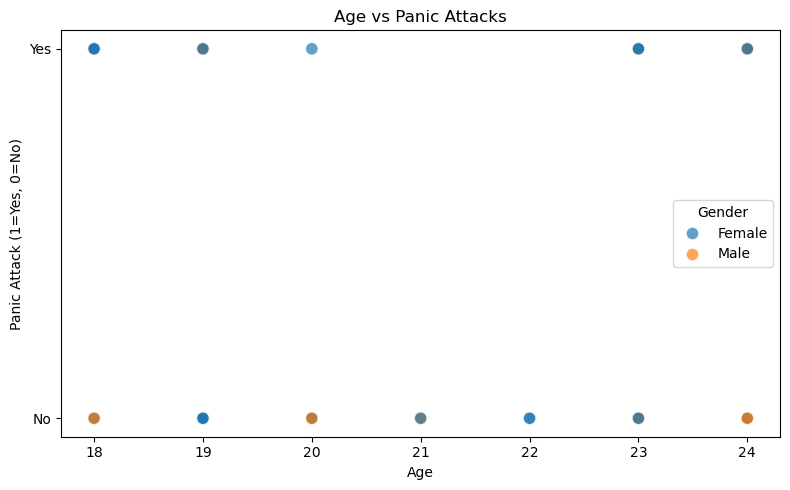

In [5]:
# Convert Panic_attack to numeric
df['Panic_numeric'] = df['Panic_attack'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Age', y='Panic_numeric', hue='Gender', alpha=0.7, s=80)

plt.title('Age vs Panic Attacks')
plt.xlabel('Age')
plt.ylabel('Panic Attack (1=Yes, 0=No)')
plt.yticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()

## Exercise 4 — Pairplot of Age, CGPA & Mental Health

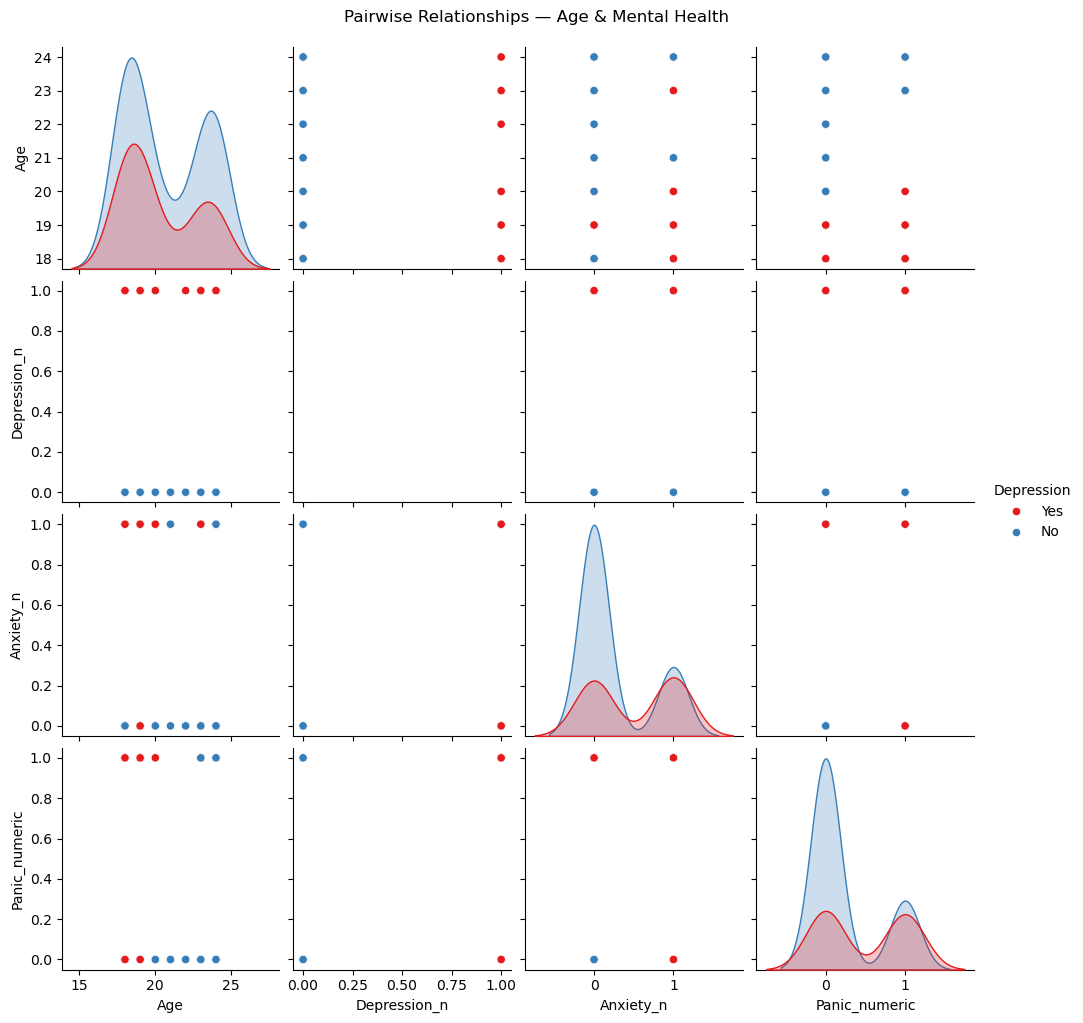

In [6]:
# Convert mental health columns to numeric
df['Depression_n'] = df['Depression'].map({'Yes': 1, 'No': 0})
df['Anxiety_n']    = df['Anxiety'].map({'Yes': 1, 'No': 0})

subset = df[['Age', 'Depression_n', 'Anxiety_n', 'Panic_numeric', 'Depression']].dropna()

sns.pairplot(subset, hue='Depression', palette='Set1')
plt.suptitle('Pairwise Relationships — Age & Mental Health', y=1.02)
plt.show()

## Exercise 5 — Correlation Heatmap

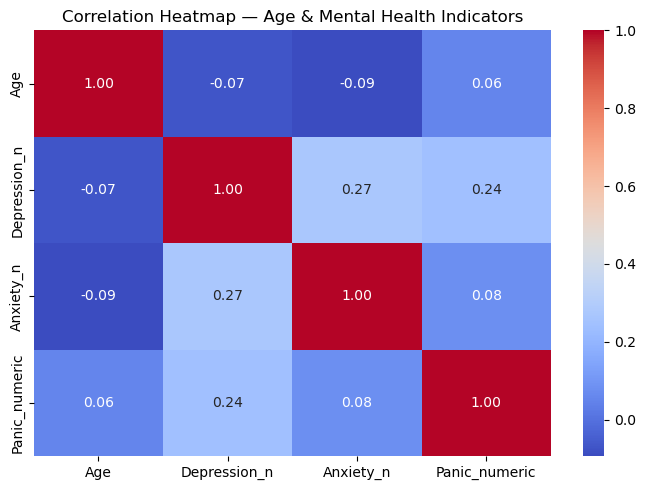

In [7]:
corr_df = df[['Age', 'Depression_n', 'Anxiety_n', 'Panic_numeric']].dropna()
corr_matrix = corr_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Heatmap — Age & Mental Health Indicators')
plt.tight_layout()
plt.show()

## Exercise 6 — CGPA Distribution by Depression Status (FacetGrid)

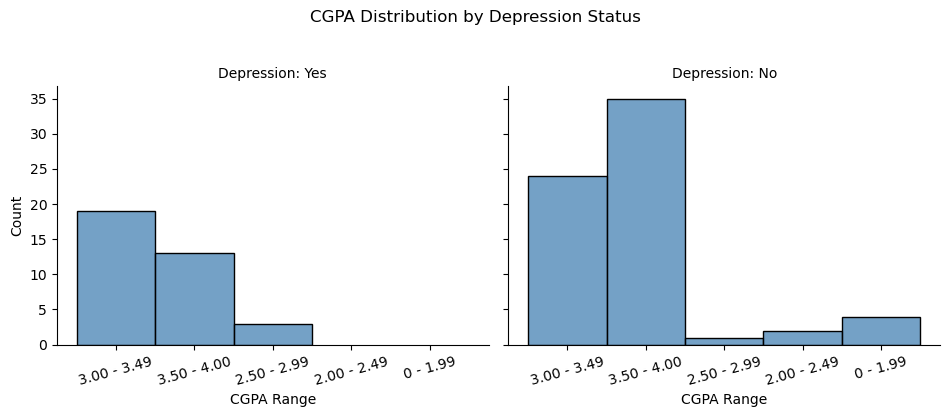

In [8]:
g = sns.FacetGrid(df, col='Depression', height=4, aspect=1.2)
g.map(sns.histplot, 'CGPA', color='steelblue')

g.set_axis_labels('CGPA Range', 'Count')
g.set_titles(col_template='Depression: {col_name}')
g.figure.suptitle('CGPA Distribution by Depression Status', y=1.03)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()